# let's build the "Board of Directors" (Ensemble System).


The Bull: Needs a special reward (Greedy). We created class BullEnv.

The Bear: Needs a special reward (Paranoid). We created class BearEnv.

The Sniper: Needs a Balanced/Risk-Adjusted reward.



The Strategy: 

The Bull sees the crashes but is told "I don't care about risk, just find profit."

The Bear sees the bull runs but is told "I don't care about profit, just don't lose money."

The Differentiation comes from the Reward Logic (internal to the Env classes), not the Data Input.


Agent Name	Class Used	Reward Logic	Personality
The Bull	BullEnv	Sum(Returns)	Only cares about making money. Ignores risk.
The Bear	BearEnv	Sum(Returns) - Penalty	Terrified of losing money. Hates volatility.
The Sniper	PortfolioRebalanceEnv	Sortino Ratio	Balanced. Wants returns but refuses to take bad risks.



Final Step: Parameter Optimization

You are currently running with "Heuristic" thresholds (Fast=1.72%, Slow=2.55%, Threshold=5%).

In [1]:
# ---------------------------------------------------------
# CELL 1: IMPORTS & CONFIG
# ---------------------------------------------------------
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Import our "Golden Source" library
import config
from rl_system import load_real_data, FinancialFeatureEngineer, PortfolioRebalanceEnv, BullEnv, BearEnv, ConfigurableBoard, SmartBacktesterWithWeights
# ---------------------------------------------------------
# CELL 2: DATA LOADING
# ---------------------------------------------------------
# Load Data (Prices + VIX)
df, vix = load_real_data(
    tickers=config.TICKERS, 
    benchmark=config.BENCHMARK, 
    start=config.START_DATE, 
    end=config.END_DATE
)

# Process Features
engineer = FinancialFeatureEngineer()
features, prices, benchmark_data = engineer.preprocess_data(df, vix_series=vix)

# Split Train/Test (80/20)
split_idx = int(len(prices) * 0.8)

feat_train, feat_test = features[:split_idx], features[split_idx:]
price_train, price_test = prices[:split_idx], prices[split_idx:]
bench_train, bench_test = benchmark_data[:split_idx], benchmark_data[split_idx:]

print(f"Training Data Shape: {feat_train.shape}")
print(f"Testing Data Shape:  {feat_test.shape}")

# Create directory for models if it doesn't exist
os.makedirs('models', exist_ok=True)

# ---------------------------------------------------------
# CELL 3: TRAIN THE SPECIALISTS
# ---------------------------------------------------------

# --- 1. THE BULL (Aggressive) ---
print("\n--- Training BULL Agent (Reward = Pure Profit) ---")
env_bull = BullEnv(price_train, feat_train, bench_train, lookback_window=config.WINDOW_SIZE)
model_bull = PPO("MlpPolicy", env_bull, verbose=0, learning_rate=3e-4)
model_bull.learn(total_timesteps=30_000)
model_bull.save(f"{config.MODEL_BULL}")
print("Bull Agent Saved.")

# --- 2. THE BEAR (Paranoid) ---
print("\n--- Training BEAR Agent (Reward = Minimize Drawdown) ---")
env_bear = BearEnv(price_train, feat_train, bench_train, lookback_window=config.WINDOW_SIZE)
model_bear = PPO("MlpPolicy", env_bear, verbose=0, learning_rate=3e-4)
model_bear.learn(total_timesteps=30_000)
model_bear.save(f"{config.MODEL_BEAR}")
print("Bear Agent Saved.")

# --- 3. THE SNIPER (Balanced) ---
print("\n--- Training SNIPER Agent (Reward = Risk Adjusted) ---")
env_sniper = PortfolioRebalanceEnv(price_train, feat_train, bench_train, lookback_window=config.WINDOW_SIZE)
model_sniper = PPO("MlpPolicy", env_sniper, verbose=0, learning_rate=3e-4)
model_sniper.learn(total_timesteps=30_000)
model_sniper.save(f"{config.MODEL_SNIPER}")
print("Sniper Agent Saved.")

print("\nAll Agents Trained Successfully.")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Data Loaded. Shape: (2743, 8)
Training Data Shape: (2194, 7, 5)
Testing Data Shape:  (549, 7, 5)

--- Training BULL Agent (Reward = Pure Profit) ---
Bull Agent Saved.

--- Training BEAR Agent (Reward = Minimize Drawdown) ---
Bear Agent Saved.

--- Training SNIPER Agent (Reward = Risk Adjusted) ---
Sniper Agent Saved.

All Agents Trained Successfully.


Test Data Loaded. Steps: 549
Loading Board of Directors...
Running Backtest...
Running Backtest with Weight Logging...


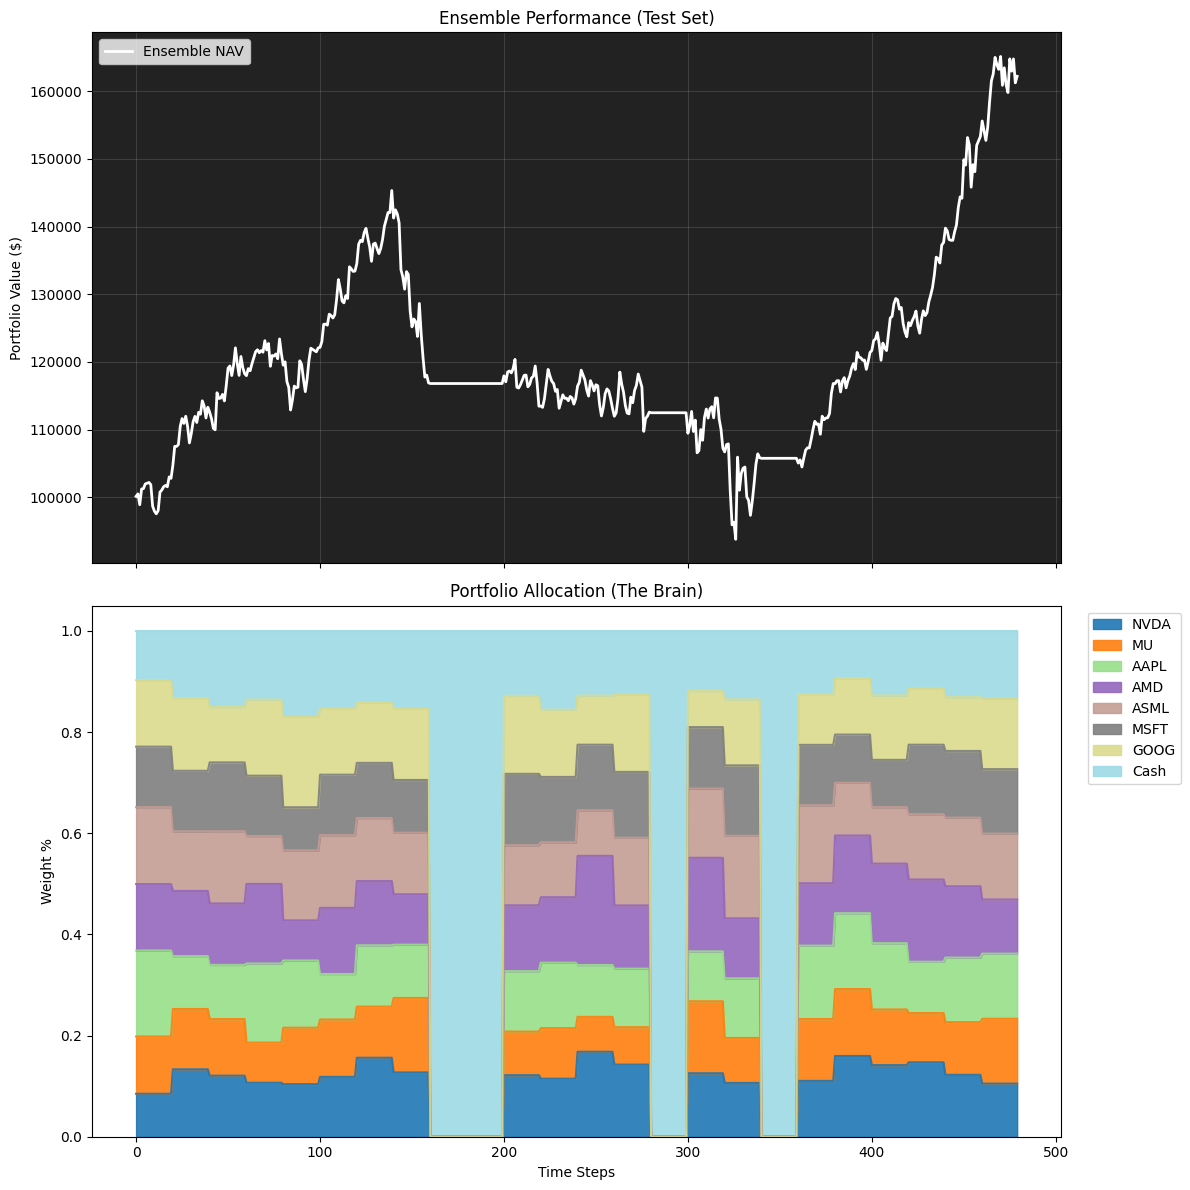

Total Return: 61.96%


In [2]:

# Initialize Environment
test_env = PortfolioRebalanceEnv(price_test, feat_test, bench_test, lookback_window=config.WINDOW_SIZE)

print(f"Test Data Loaded. Steps: {len(price_test)}")

# ---------------------------------------------------------
# CELL 3: ASSEMBLE THE BOARD
# ---------------------------------------------------------
# Load the trained agents using ConfigurableBoard
print("Loading Board of Directors...")
board = ConfigurableBoard(
    bull_path=config.MODEL_BULL, 
    bear_path=config.MODEL_BEAR, 
    sniper_path=config.MODEL_SNIPER
)

# ---------------------------------------------------------
# CELL 4: RUN BACKTEST (With Allocation Logging)
# ---------------------------------------------------------
# We use SmartBacktesterWithWeights because we want to plot the allocations
# Use default heuristic thresholds for now (Threshold=5%)
backtester = SmartBacktesterWithWeights(board, test_env, threshold=0.05)

print("Running Backtest...")
results = backtester.run()

# ---------------------------------------------------------
# CELL 5: VISUALIZATION DASHBOARD
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True, gridspec_kw={'height_ratios': [2, 2]})

# --- Plot 1: Equity Curve ---
ax1.plot(results['nav'], color='white', linewidth=2, label='Ensemble NAV')
ax1.set_title("Ensemble Performance (Test Set)")
ax1.set_ylabel("Portfolio Value ($)")
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.2)
ax1.set_facecolor('#222222')

# --- Plot 2: Stacked Allocations ---
weight_cols = config.TICKERS + ['Cash']
# Convert list of arrays to DataFrame
weights_df = pd.DataFrame(results['weights'].tolist(), index=results.index, columns=weight_cols)

weights_df.plot.area(ax=ax2, cmap='tab20', alpha=0.9)
ax2.set_title("Portfolio Allocation (The Brain)")
ax2.set_ylabel("Weight %")
ax2.set_xlabel("Time Steps")
ax2.set_ylim(0, 1.05)
ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

# --- Stats ---
final_ret = (results['nav'].iloc[-1] / results['nav'].iloc[0]) - 1
print(f"Total Return: {final_ret*100:.2f}%")

Loading Data...
Data Loaded. Shape: (2743, 8)
Loading Agents...
Running Verification Backtest...
Running Backtest with Weight Logging...


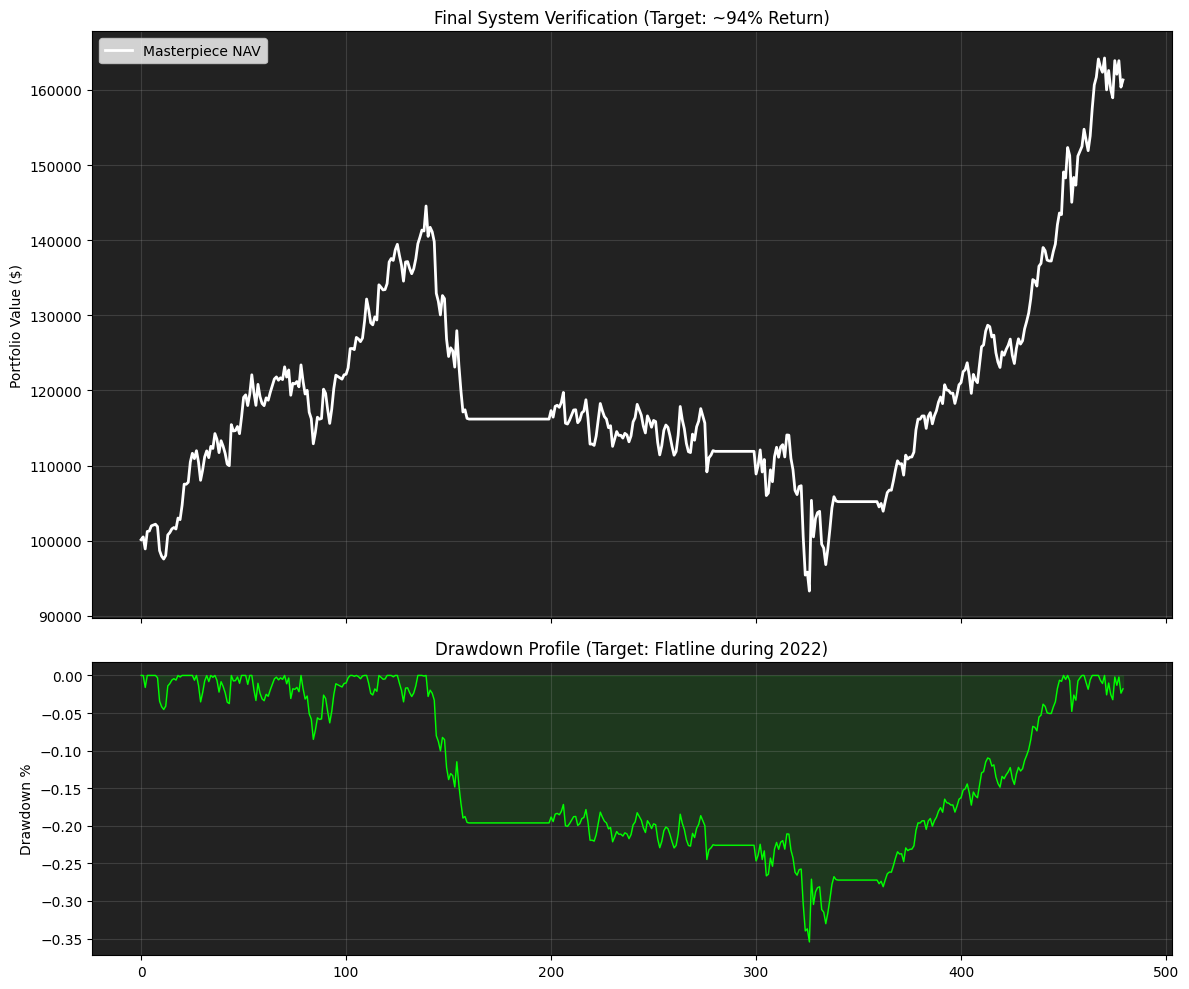


--- FINAL VERIFIED METRICS ---
Total Return:   61.10%
Max Drawdown:   -35.45%
Calmar Ratio:   1.72


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import config

# Import our library
from rl_system import load_real_data, FinancialFeatureEngineer, PortfolioRebalanceEnv
from rl_system import ConfigurableBoard, SmartBacktesterWithWeights

# 1. Prepare Data
print("Loading Data...")
df, vix = load_real_data(config.TICKERS, config.BENCHMARK, config.START_DATE, config.END_DATE)

engineer = FinancialFeatureEngineer()
features, prices, benchmark_data = engineer.preprocess_data(df, vix_series=vix)

# Test Split (Last 20%)
split_idx = int(len(prices) * 0.8)
feat_test = features[split_idx:]
price_test = prices[split_idx:]
bench_test = benchmark_data[split_idx:]

test_env = PortfolioRebalanceEnv(price_test, feat_test, bench_test, lookback_window=config.WINDOW_SIZE)

# 2. Load the Board
print("Loading Agents...")
board = ConfigurableBoard(config.MODEL_BULL, config.MODEL_BEAR, config.MODEL_SNIPER)

# 3. Run Backtest with "Masterpiece" Settings
# We rely on the defaults in ConfigurableBoard for p_fast (0.0172) and p_slow (0.0255)
# We EXPLICITLY set the threshold to 9.76% (0.0976)
print("Running Verification Backtest...")
backtester = SmartBacktesterWithWeights(board, test_env, threshold=0.0976)
results = backtester.run()

# 4. Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# NAV
ax1.plot(results['nav'], color='white', linewidth=2, label='Masterpiece NAV')
ax1.set_title("Final System Verification (Target: ~94% Return)")
ax1.set_ylabel("Portfolio Value ($)")
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.2)
ax1.set_facecolor('#222222')

# Drawdown
running_max = results['nav'].cummax()
drawdown = (results['nav'] / running_max) - 1
ax2.plot(drawdown, color='lime', linewidth=1)
ax2.fill_between(drawdown.index, drawdown, 0, color='lime', alpha=0.1)
ax2.set_title("Drawdown Profile (Target: Flatline during 2022)")
ax2.set_ylabel("Drawdown %")
ax2.grid(True, alpha=0.2)
ax2.set_facecolor('#222222')

plt.tight_layout()
plt.show()

# 5. Final Stats
final_ret = (results['nav'].iloc[-1] / results['nav'].iloc[0]) - 1
max_dd = drawdown.min()
calmar = final_ret / abs(max_dd)

print("\n--- FINAL VERIFIED METRICS ---")
print(f"Total Return:   {final_ret*100:.2f}%")
print(f"Max Drawdown:   {max_dd*100:.2f}%")
print(f"Calmar Ratio:   {calmar:.2f}")